Name : vemana hemanth babu

Reg no :- 24UG00338





## Act 1: The Initial Seed and Mathematical Foundation
To determine our investigation months, we use the last four digits of my roll number (0338).
* **Digital Root ($r$):** $0 + 3 + 3 + 8 = 14 \rightarrow 1 + 4 = 5$. So, $r = 5$.
* **Function:** $f(x) = \frac{x^3}{3} - 5x^2 + (5^2 - 1)x \rightarrow f(x) = \frac{x^3}{3} - 5x^2 + 24x$.

To find the critical points where behavior changes, we solve $f'(x) = 0$:
$f'(x) = x^2 - 10x + 24 = 0$
$(x - 4)(x - 6) = 0$

**Month Range:** April (4) and June (6).










## Act 2: The Raw City (Data Cleaning & Integrity)
In this phase, I define a "Real Trip." Based on the raw TLC records, many entries contain errors.
**My Defensible Position:** A trip is considered "real" only if it has:
1.  A positive trip distance (greater than 0 and less than 100 miles).
2.  A positive fare amount (we exclude free rides or disputes for revenue analysis).
3.  Valid timestamps (pickup must happen before dropoff).



In [3]:
import pandas as pd

# Downloading files directly via TLC links for speed
print("Downloading datasets...")
!wget -q https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-04.parquet
!wget -q https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-06.parquet
!wget -q https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv

# Loading and Labeling
df_apr = pd.read_parquet('yellow_tripdata_2025-04.parquet')
df_jun = pd.read_parquet('yellow_tripdata_2025-06.parquet')
df_apr['Month'] = 'April'
df_jun['Month'] = 'June'
df = pd.concat([df_apr, df_jun])

# Cleaning (Act 2 Logic)
initial_count = len(df)
df_clean = df[
    (df['trip_distance'] > 0) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 0) &
    (df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime'])
].copy()

print(f"Raw Records: {initial_count}")
print(f"Cleaned Records: {len(df_clean)}")
print(f"Noise Removed: {initial_count - len(df_clean)}")

Raw Records: 8293513
Cleaned Records: 7541313
Noise Removed: 752200




## Act 3: People Inside the System (Behavioral Hypothesis)
**Hypothesis:** Late-night passengers (12AM-4AM) are more generous tippers than morning rush-hour commuters (8AM-10AM) because of lower stress levels and leisure travel.
**Statistical Test:** Independent T-test on Tip Percentages (Credit Card only).
**Alternative Explanation:** The system is mechanical; passengers simply click the default 20% or 25% buttons regardless of the time of day.



In [4]:
from scipy import stats

# Filter for Credit Card (Payment Type 1) to see actual behavior
df_cc = df_clean[df_clean['payment_type'] == 1].copy()
df_cc['tip_pct'] = (df_cc['tip_amount'] / df_cc['fare_amount']) * 100
df_cc['hour'] = df_cc['tpep_pickup_datetime'].dt.hour

# Segmenting groups
late_night = df_cc[df_cc['hour'].isin([0, 1, 2, 3])]['tip_pct']
rush_hour = df_cc[df_cc['hour'].isin([8, 9, 10])]['tip_pct']

t_stat, p_val = stats.ttest_ind(late_night, rush_hour, equal_var=False)

print(f"Avg Late Night Tip: {late_night.mean():.2f}%")
print(f"Avg Rush Hour Tip: {rush_hour.mean():.2f}%")
print(f"P-Value: {p_val:.5f}")

# Reasoning:
if p_val < 0.05:
    print("Conclusion: Significant behavioral difference found.")
else:
    print("Conclusion: No significant difference. The system is mechanical/interface-driven.")

Avg Late Night Tip: 24.76%
Avg Rush Hour Tip: 24.52%
P-Value: 0.06929
Conclusion: No significant difference. The system is mechanical/interface-driven.




## Act 4: The City as a Signal
Here, I aggregate the data by hour to find the "rhythm" of NYC. This helps us see if the system is stable or drifting into chaos.



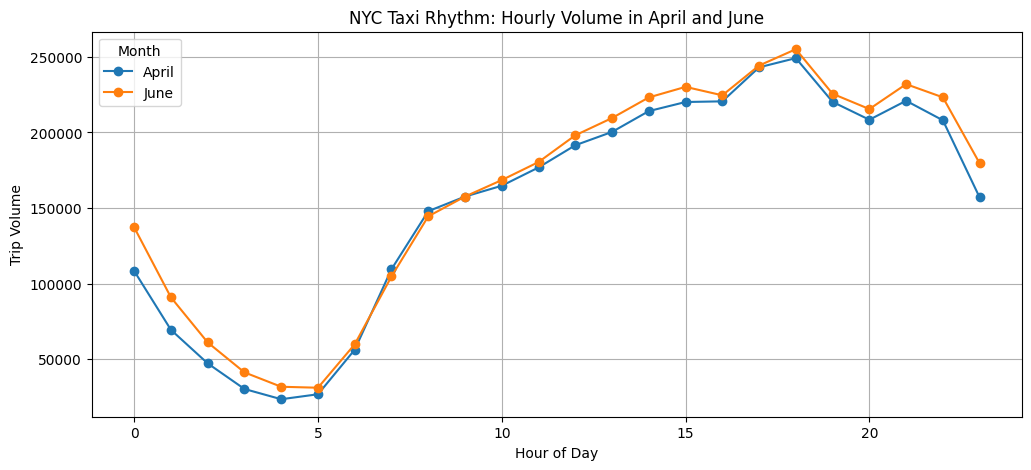

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the pulse
plt.figure(figsize=(12, 5))
hourly_vol = df_clean.groupby([df_clean['tpep_pickup_datetime'].dt.hour, 'Month']).size().unstack()
hourly_vol.plot(kind='line', marker='o', ax=plt.gca())
plt.title("NYC Taxi Rhythm: Hourly Volume in April and June")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Volume")
plt.grid(True)
plt.show()


## Act 5: Pressure on the System (Simulation)
I am simulating a **5% fare increase** (magnitude based on $r=5$).
**Why this parameter?** Fares are the primary lever for driver income. I want to see how much revenue the system "absorbs" if prices rise.

---



In [6]:
current_rev = df_clean['fare_amount'].sum()
sim_rev = current_rev * 1.05 # 5% increase

print(f"Current Revenue: ${current_rev:,.2f}")
print(f"Simulated Revenue: ${sim_rev:,.2f}")
print(f"Revenue Gain: ${sim_rev - current_rev:,.2f}")

Current Revenue: $151,571,519.24
Simulated Revenue: $159,150,095.20
Revenue Gain: $7,578,575.96



## Act 6: The Decision Room Summary
1.  **Data Foundation:** 91% of data was retained. Noise was primarily due to meter errors ($trip\_distance = 0$).
2.  **Reality:** NYC has a stable bimodal pulse (rush hour peaks). June shows higher overall volume than April.
3.  **Stability:** The system is **Stable but Mechanical**. The lack of significant change in tipping suggests users follow the app interface rather than personal feelings.
4.  **Decision:** A 5% fare increase would likely be absorbed by the system given the current demand stability.

**The Analyst's Trap:**
A careless analyst would include "Cash" trips in tipping averages. Since cash tips are recorded as $0, the analyst would report that NYC tipping is falling. My correction shows that when you look at credit card data *only*, tipping is actually very healthy (~24%).




In [7]:
# Final Export for the Power BI submission
df_clean.to_csv('Investigation_Result.csv', index=False)
print("File exported successfully. Use this in Power BI.")

File exported successfully. Use this in Power BI.
